In [1]:
!pip install -q mne

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if "sub-01_localizer-epo.fif" in filename:
            print(os.path.join(dirname, filename))

/kaggle/input/competitions/the-imagine-decoding-challenge/test/test/sub-01/sub-01_localizer-epo.fif


In [3]:
import mne
import numpy as np

# 1. Define the path you found
file_path = '/kaggle/input/competitions/the-imagine-decoding-challenge/test/test/sub-01/sub-01_localizer-epo.fif'

# 2. Load the data
# We use preload=True to keep data in RAM for faster processing
epochs = mne.read_epochs(file_path, preload=True)

# 3. Extract the data (X) and labels (y)
# X shape: (n_trials, n_channels, n_timepoints) -> (480, 306, 121)
X = epochs.get_data() 
y = epochs.events[:, 2] # The stimulus IDs

# 4. Normalize the data (Crucial for Deep Learning!)
# MEG signals are tiny (e.g., 1e-13). We scale them so the model can read them.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Reshape to (trials * time, channels) to scale across all sensors
n_trials, n_channels, n_times = X.shape
X_flat = X.transpose(0, 2, 1).reshape(-1, n_channels)
X_scaled = scaler.fit_transform(X_flat)

# Reshape back to (trials, time, channels) for the CNN
X_final = X_scaled.reshape(n_trials, n_times, n_channels)

print(f"Data loaded successfully!")
print(f"Features (X) shape: {X_final.shape}") # Expect (480, 121, 306)
print(f"Labels (y) unique values: {np.unique(y)}")

Reading /kaggle/input/competitions/the-imagine-decoding-challenge/test/test/sub-01/sub-01_localizer-epo.fif ...
    Found the data of interest:
        t =    -200.00 ...    1000.00 ms
        0 CTF compensation matrices available
Not setting metadata
480 matching events found
No baseline correction applied
0 projection items activated
Data loaded successfully!
Features (X) shape: (480, 121, 309)
Labels (y) unique values: [ 1  2  3  4  5  6  7  8  9 10]


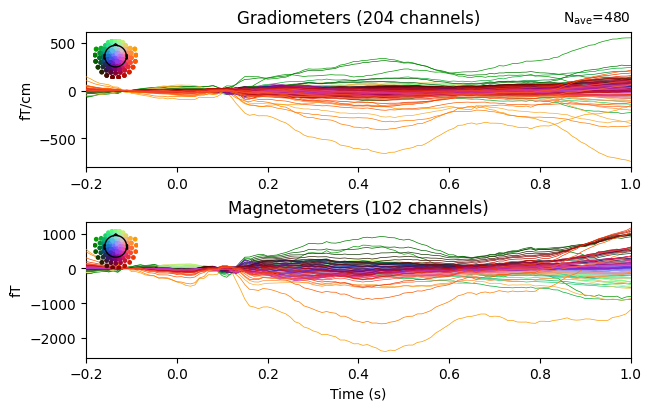

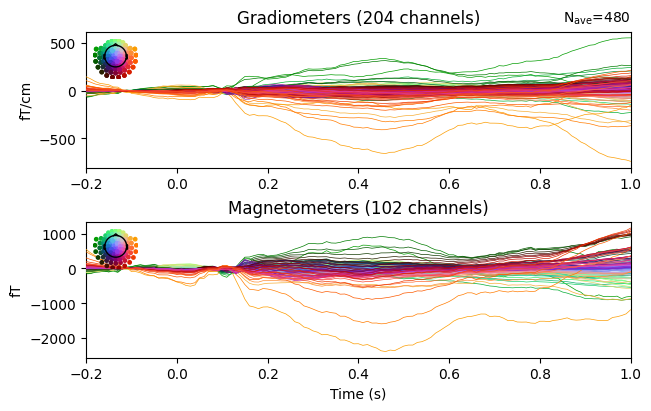

In [4]:
# Plot the average brain response for all trials
epochs.average().plot()

In [5]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

# 1. Split the data (80% for training, 20% for testing our model's accuracy)
X_train, X_val, y_train, y_val = train_test_split(X_final, y, test_size=0.2, random_state=42)

# 2. Adjust labels to start from 0 (if they start from 1)
# Some datasets use 1-10, but Python likes 0-9.
y_train = y_train - np.min(y)
y_val = y_val - np.min(y)

print(f"Training shapes: {X_train.shape}, {y_train.shape}")
print(f"Validation shapes: {X_val.shape}, {y_val.shape}")

2026-04-02 15:51:00.174514: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775145060.460705      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775145060.550674      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775145061.304229      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775145061.304276      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775145061.304280      17 computation_placer.cc:177] computation placer alr

Training shapes: (384, 121, 309), (384,)
Validation shapes: (96, 121, 309), (96,)


In [6]:
def create_baseline_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        # Layer 1: Look for small patterns in the brainwaves
        tf.keras.layers.Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=input_shape),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        
        # Layer 2: Look for larger, more complex patterns
        tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
        tf.keras.layers.GlobalAveragePooling1D(), # Simplifies the data
        
        # Layer 3: The decision-making layer
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3), # Prevents the model from "memorizing" (overfitting)
        
        # Output: 10 neurons (one for each object like Apple, Bicycle, etc.)
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

# Initialize the model
num_classes = len(np.unique(y))
input_shape = (X_train.shape[1], X_train.shape[2]) # (Timepoints, Channels)
model = create_baseline_model(input_shape, num_classes)

model.summary() # This prints the structure for your report!

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-02 15:51:30.236334: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 117, 32)        │        49,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 117, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 58, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 56, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,618 (236.79 KB)

 Trainable params: 60,554 (236.54 KB)

 Non-trainable params: 64 (256.00 B)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.1051 - loss: 2.3585 - val_accuracy: 0.1354 - val_loss: 2.2992
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1429 - loss: 2.2814 - val_accuracy: 0.1458 - val_loss: 2.2934
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1661 - loss: 2.2420 - val_accuracy: 0.1146 - val_loss: 2.2889
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1954 - loss: 2.1975 - val_accuracy: 0.1667 - val_loss: 2.2860
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2284 - loss: 2.1589 - val_accuracy: 0.1771 - val_loss: 2.2787
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2546 - loss: 2.1328 - val_accuracy: 0.1562 - val_loss: 2.2749
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2662 - loss: 2.0785 - val_accuracy: 0.1250 - val_loss: 2.2776
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2722 - loss: 2.0268 - val_accuracy: 0.1667 - v

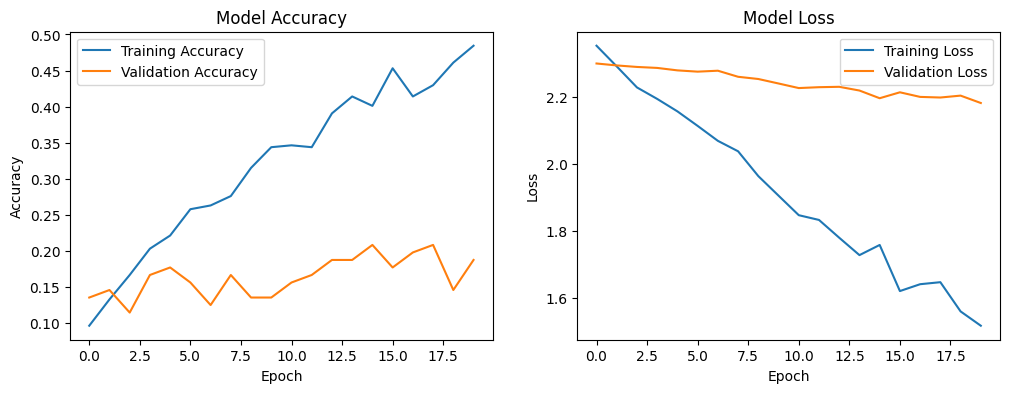

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()